# NLCD Land Cover Layer Authoring for RASMapper

Create a RASMapper land-cover sidecar HDF from an NLCD-coded raster, register it in `.rasmap`, write the authoritative base Manning's n table to the plain-text geometry file, and associate the compiled geometry HDF with the new layer.

This workflow uses `BaldEagleCrkMulti2D` for reproducibility. The project already includes a local NLCD-coded land-cover raster, so the notebook is offline-safe; production workflows can use Annual NLCD downloads from USGS/MRLC through EarthExplorer, the MRLC viewer or mosaic download site, ScienceBase, Annual NLCD web services, or USGS AWS S3 in `us-west-2`.


## Workflow Scope

| Workflow step | ras-commander API used here | Status |
|---|---|---|
| NLCD code table for sidecar authoring | `ManningsFromLandCover.default_landcover_classification_table()` | Added for notebook 212; emits RAS-safe class names. |
| Land-cover sidecar HDF + GeoTIFF | `RasMap.add_landcover_layer()` | Creates `Raster Map`, `Variables`, sidecar HDF, sidecar GeoTIFF, and `.rasmap` registration. |
| RASMapper layer catalog registration | `RasMap.list_landcover_layers()` | Confirms the new `LandCoverLayer` entry in `.rasmap`. |
| Authoritative base Manning's n values | `GeomLandCover.replace_base_mannings_n()` | Replaces or creates the plain-text `LCMann Table=` block in `.g##`. |
| Enable spatially varied Manning's n | `GeomStorage.set_2d_flow_area_settings()` | Sets `spatially_varied_mann_on_faces=True` so HEC-RAS imports the land cover table. |
| Geometry HDF layer association | `RasMap.associate_geometry_layers()` | Writes `/Geometry` association attributes for terrain and land cover. |
| Full HEC-RAS geometry compile | `RasCmdr.compute_plan(clear_geompre=True)` | Clears `.c##` files (preserves `.g##.hdf` associations), forces geometry recompilation. Opt-in via `RUN_HECRAS_PREPROCESSOR`. |

Key constraint: the sidecar HDF stores pixel-to-class mapping and starter variables for RASMapper display. The plain-text geometry `LCMann Table=` is the authoritative source for base Manning's n values that HEC-RAS imports during geometry preprocessing. The `spatially_varied_mann_on_faces` flag must be enabled for HEC-RAS to use the land cover table. Use `clear_geompre` (not `force_geompre`) to preserve the `.g##.hdf` land cover association.

In [1]:
from pathlib import Path
import logging

import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display

from ras_commander import (
    GeomLandCover,
    RasCmdr,
    RasExamples,
    RasMap,
    init_ras_project,
    ras,
)
from ras_commander.geom import GeomStorage
from ras_commander.geom.ManningsFromLandCover import ManningsFromLandCover
from ras_commander.hdf import HdfLandCover

for logger_name in [
    "ras_commander.RasExamples",
    "ras_commander.RasMap",
    "ras_commander.RasPrj",
    "ras_commander.RasUtils",
    "ras_commander.hdf.HdfBase",
    "ras_commander.hdf.HdfLandCover",
]:
    logging.getLogger(logger_name).setLevel(logging.WARNING)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 180,
    "axes.titlesize": 13,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
})

RAS_VERSION = "7.0"
GEOMETRY_NUMBER = "12"
AUTHORED_LAYER_NAME = "NLCD Land Cover 212"
AUTHORED_HDF_NAME = "LandCover_NLCD_212.hdf"
CELL_SIZE_FT = 100.0
RUN_HECRAS_PREPROCESSOR = True

## Extract the Example Project

Use the reproducible Bald Eagle multi-2D example and target geometry `g12`, the smallest 2D geometry in this project. The smaller mesh keeps sidecar authoring and visual review fast while still exercising the same RASMapper land-cover contracts.


In [2]:
project_path = RasExamples.extract_project('BaldEagleCrkMulti2D')
init_ras_project(project_path, RAS_VERSION)
project_path = Path(project_path)

geom_row = ras.geom_df.loc[
    ras.geom_df["geom_number"].astype(str).str.zfill(2) == GEOMETRY_NUMBER
].iloc[0]
plan_row = ras.plan_df.loc[
    ras.plan_df["geometry_number"].astype(str).str.zfill(2) == GEOMETRY_NUMBER
].iloc[0]

geometry_path = Path(geom_row["full_path"])
geometry_hdf_path = Path(geom_row["hdf_path"])
plan_number = str(plan_row["plan_number"]).zfill(2)
source_nlcd_raster = project_path / "Land Classification" / "LandCover.tif"
authored_hdf_path = project_path / "Land Classification" / AUTHORED_HDF_NAME

summary = pd.DataFrame([
    {"item": "project", "value": project_path.name},
    {"item": "plan", "value": plan_number},
    {"item": "geometry", "value": geometry_path.name},
    {"item": "2D cell count", "value": int(geom_row["mesh_cell_count"])},
    {"item": "source NLCD raster", "value": source_nlcd_raster.name},
])
display(summary)


,item,value
0,project,BaldEagleCrkMulti2D
1,plan,19
2,geometry,BaldEagleDamBrk.g12
3,2D cell count,3439
4,source NLCD raster,LandCover.tif


## Clip Extent and Classification Table

The notebook clips the source raster to the target 2D mesh extent with a 500 ft buffer and writes the sidecar at an NLCD-scale 100 ft grid. `default_landcover_classification_table()` maps NLCD raster codes to sidecar class IDs, RAS-safe class names, starter Manning's n values, and optional percent impervious values.


In [3]:
def mesh_bounds_from_geometry_hdf(hdf_path: Path, buffer_ft: float = 500.0) -> tuple[float, float, float, float]:
    with h5py.File(hdf_path, "r") as hdf_file:
        coords = hdf_file["Geometry/2D Flow Areas/Cell Points"][()]
    left, bottom = coords.min(axis=0)
    right, top = coords.max(axis=0)
    return (
        float(left - buffer_ft),
        float(bottom - buffer_ft),
        float(right + buffer_ft),
        float(top + buffer_ft),
    )

mesh_extent = mesh_bounds_from_geometry_hdf(geometry_hdf_path)
percent_impervious = {
    11: 100.0,
    21: 10.0,
    22: 25.0,
    23: 55.0,
    24: 85.0,
}
classification_table = ManningsFromLandCover.default_landcover_classification_table(
    percent_impervious=percent_impervious,
)
base_mannings_table = pd.concat(
    [
        pd.DataFrame([
            {"Land Cover Name": "NoData", "Base Mannings n Value": 0.035}
        ]),
        classification_table.rename(
            columns={
                "class_name": "Land Cover Name",
                "mannings_n": "Base Mannings n Value",
            }
        )[["Land Cover Name", "Base Mannings n Value"]],
    ],
    ignore_index=True,
)

with rasterio.open(source_nlcd_raster) as src:
    source_profile = {
        "width": src.width,
        "height": src.height,
        "cell_size_ft": abs(float(src.transform.a)),
        "crs": str(src.crs),
    }

display(pd.DataFrame([source_profile]))
display(classification_table.head(12))
assert not classification_table["class_name"].str.contains(r"[\/]", regex=True).any()


,width,height,cell_size_ft,crs
0,14765,10318,10.0,EPSG:2271


,source_value,class_id,class_name,mannings_n,percent_impervious
0,11,11,Open Water,0.025,100.0
1,12,12,Perennial Ice-Snow,0.030,0.0
2,21,21,"Developed, Open Space",0.040,10.0
3,22,22,"Developed, Low Intensity",0.065,25.0
4,23,23,"Developed, Medium Intensity",0.090,55.0
5,24,24,"Developed, High Intensity",0.120,85.0
6,31,31,Barren Land,0.035,0.0
7,41,41,Deciduous Forest,0.120,0.0
8,42,42,Evergreen Forest,0.140,0.0
9,43,43,Mixed Forest,0.130,0.0


## Author and Register the Sidecar Layer

`RasMap.add_landcover_layer()` reprojects/clips/resamples the NLCD-coded raster, writes the RASMapper sidecar HDF and companion GeoTIFF, and registers a distinct `LandCoverLayer` in the project `.rasmap`.


In [4]:
authored_hdf = RasMap.add_landcover_layer(
    project_path,
    source_nlcd_raster,
    classification_table,
    cell_size=CELL_SIZE_FT,
    output_hdf_path=authored_hdf_path,
    restrict_to_extent=mesh_extent,
    layer_name=AUTHORED_LAYER_NAME,
)
authored_tif = authored_hdf.with_suffix(".tif")

raster_map = HdfLandCover.get_landcover_raster_map(authored_hdf)
landcover_layers = RasMap.list_landcover_layers(project_path)
registered = landcover_layers.loc[
    landcover_layers["resolved_path"] == str(authored_hdf)
][["name", "filename", "selected_parameter", "classification_kind"]]

with h5py.File(authored_hdf, "r") as hdf_file:
    sidecar_attrs = {
        key: hdf_file.attrs[key].decode("utf-8")
        for key in ["File Type", "LC Type", "Version"]
    }

display(pd.DataFrame([sidecar_attrs]))
display(registered)
display(raster_map.head(12))
assert sidecar_attrs == {"File Type": "HEC Land Cover", "LC Type": "LandCover", "Version": "2.0"}
assert len(registered) == 1


,File Type,LC Type,Version
0,HEC Land Cover,LandCover,2.0


,name,filename,selected_parameter,classification_kind
3,NLCD Land Cover 212,.\Land Classification\LandCover_NLCD_212.hdf,ManningsN,landcover


,pixel_value,class_name,mannings_n
0,0,NoData,0.035
1,11,Open Water,0.025
2,12,Perennial Ice-Snow,0.030
3,21,"Developed, Open Space",0.040
4,22,"Developed, Low Intensity",0.065
5,23,"Developed, Medium Intensity",0.090
6,24,"Developed, High Intensity",0.120
7,31,Barren Land,0.035
8,41,Deciduous Forest,0.120
9,42,Evergreen Forest,0.140


## Visual Check of Authored NLCD Classes

The map below is the generated sidecar GeoTIFF. It uses the clipped 2D mesh extent, project coordinates in feet, a north arrow, and a scale bar so the figure can be reviewed as an engineering map rather than a raw array dump.


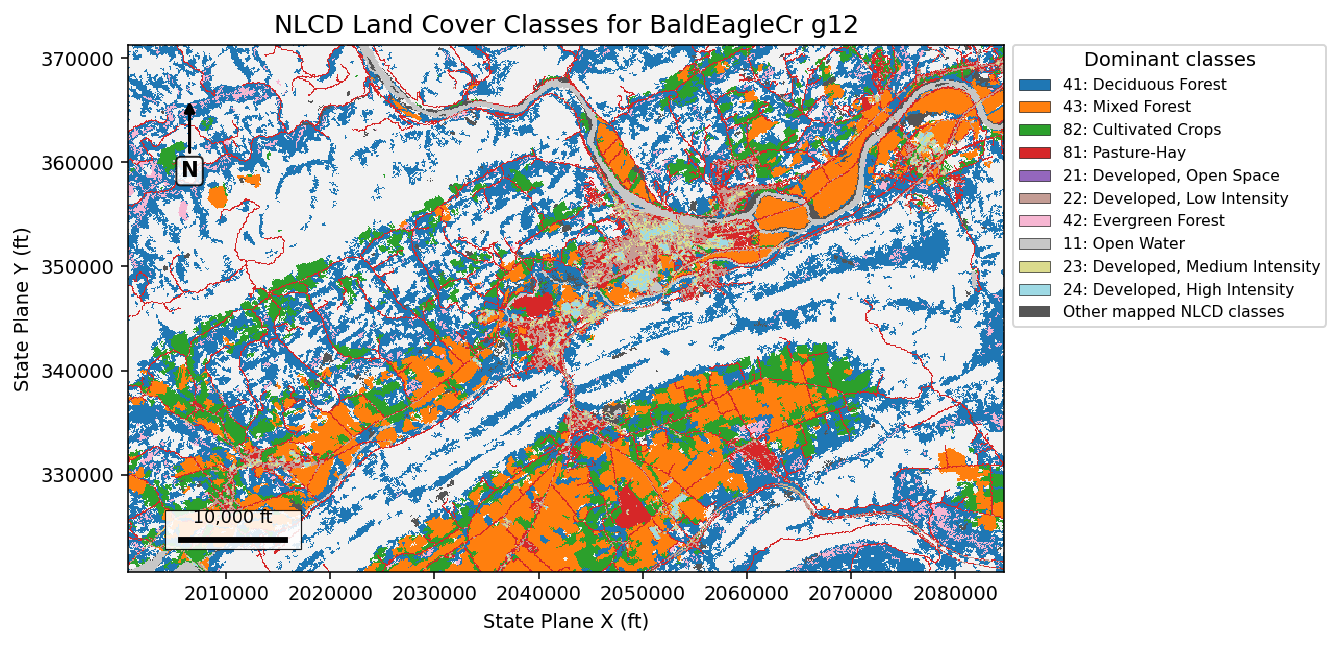

,NLCD code,class,cells,area_acres
0,41,Deciduous Forest,166391,38198.117539
1,43,Mixed Forest,108027,24799.586777
2,82,Cultivated Crops,48976,11243.342516
3,81,Pasture-Hay,35432,8134.067952
4,21,"Developed, Open Space",30025,6892.791552
5,22,"Developed, Low Intensity",11504,2640.955005
6,42,Evergreen Forest,7874,1807.621671
7,11,Open Water,6794,1559.687787
8,23,"Developed, Medium Intensity",3713,852.387511
9,24,"Developed, High Intensity",1761,404.269972


In [5]:
with rasterio.open(authored_tif) as src:
    landcover_array = src.read(1)
    bounds = src.bounds

unique_codes, counts = np.unique(landcover_array, return_counts=True)
code_to_name = dict(zip(raster_map["pixel_value"], raster_map["class_name"]))
nonzero = [(int(code), int(count)) for code, count in zip(unique_codes, counts) if int(code) != 0]
nonzero_sorted = sorted(nonzero, key=lambda item: item[1], reverse=True)
top_codes = [code for code, _ in nonzero_sorted[:10]]
plot_codes = top_codes + [code for code, _ in nonzero_sorted[10:]]
code_to_plot = {code: index + 1 for index, code in enumerate(top_codes)}
plot_array = np.zeros_like(landcover_array, dtype="int16")
for code, plot_id in code_to_plot.items():
    plot_array[landcover_array == code] = plot_id
if len(nonzero_sorted) > len(top_codes):
    other_mask = np.isin(landcover_array, [code for code, _ in nonzero_sorted[10:]])
    plot_array[other_mask] = len(top_codes) + 1

colors = ["#f2f2f2"] + list(plt.cm.tab20(np.linspace(0, 1, max(len(top_codes), 1))))
if len(nonzero_sorted) > len(top_codes):
    colors.append("#555555")
cmap = plt.matplotlib.colors.ListedColormap(colors)

fig, ax = plt.subplots(figsize=(12.0, 7.0))
extent = (bounds.left, bounds.right, bounds.bottom, bounds.top)
im = ax.imshow(plot_array, extent=extent, origin="upper", cmap=cmap, interpolation="nearest")
ax.set_title("NLCD Land Cover Classes for BaldEagleCr g12")
ax.set_xlabel("State Plane X (ft)")
ax.set_ylabel("State Plane Y (ft)")
ax.ticklabel_format(style="plain", useOffset=False)

legend_handles = [
    Patch(facecolor=colors[i + 1], edgecolor="black", linewidth=0.3,
          label=f"{code}: {code_to_name.get(code, 'Unknown')}")
    for i, code in enumerate(top_codes)
]
if len(nonzero_sorted) > len(top_codes):
    legend_handles.append(Patch(facecolor="#555555", label="Other mapped NLCD classes"))
ax.legend(
    handles=legend_handles,
    title="Dominant classes",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0.0,
    frameon=True,
)

width_ft = bounds.right - bounds.left
height_ft = bounds.top - bounds.bottom
scale_ft = 10000.0
scale_x0 = bounds.left + width_ft * 0.06
scale_y0 = bounds.bottom + height_ft * 0.06
scale_box = Rectangle(
    (scale_x0 - width_ft * 0.018, scale_y0 - height_ft * 0.018),
    scale_ft + width_ft * 0.036,
    height_ft * 0.075,
    facecolor="white",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.88,
    zorder=5,
)
ax.add_patch(scale_box)
ax.plot([scale_x0, scale_x0 + scale_ft], [scale_y0, scale_y0], color="black", linewidth=3, zorder=6)
ax.text(
    scale_x0 + scale_ft / 2,
    scale_y0 + height_ft * 0.025,
    "10,000 ft",
    ha="center",
    va="bottom",
    fontsize=9,
    zorder=7,
)
ax.annotate(
    "N",
    xy=(0.07, 0.90),
    xytext=(0.07, 0.76),
    xycoords="axes fraction",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "edgecolor": "black", "alpha": 0.85},
    arrowprops={"arrowstyle": "-|>", "linewidth": 1.6, "color": "black"},
)

plt.tight_layout(rect=[0.0, 0.0, 0.78, 1.0])
plt.show()

area_summary = pd.DataFrame(
    [
        {
            "NLCD code": code,
            "class": code_to_name.get(code, "Unknown"),
            "cells": count,
            "area_acres": count * CELL_SIZE_FT * CELL_SIZE_FT / 43560.0,
        }
        for code, count in nonzero_sorted
    ]
)
display(area_summary.head(12))


## Write the Authoritative Geometry Manning's n Table

The sidecar `Variables/ManningsN` values are useful for RASMapper display, but the plain-text geometry file is the authoritative source HEC-RAS imports during preprocessing. `replace_base_mannings_n()` writes the complete class table, including classes that may not appear in this clipped raster but can appear in a full NLCD mosaic.


In [6]:
GeomLandCover.replace_base_mannings_n(
    geometry_path,
    base_mannings_table,
    table_number="16",
)
written_table = GeomLandCover.get_base_mannings_n(geometry_path)

display(written_table.head(12))
assert set(base_mannings_table["Land Cover Name"]) == set(written_table["Land Cover Name"])
assert (geometry_path.with_suffix(geometry_path.suffix + ".bak")).exists()


,Table Number,Land Cover Name,Base Mannings n Value
0,16,NoData,0.035
1,16,Open Water,0.025
2,16,Perennial Ice-Snow,0.030
3,16,"Developed, Open Space",0.040
4,16,"Developed, Low Intensity",0.065
5,16,"Developed, Medium Intensity",0.090
6,16,"Developed, High Intensity",0.120
7,16,Barren Land,0.035
8,16,Deciduous Forest,0.120
9,16,Evergreen Forest,0.140


## Enable Spatially Varied Manning's n on 2D Faces

HEC-RAS only imports the `LCMann Table` into per-cell values when `spatially_varied_mann_on_faces` is enabled in the 2D flow area settings. Without this flag, HEC-RAS assigns the uniform base Manning's n to every cell regardless of the land cover table.

In [7]:
settings_before = GeomStorage.get_2d_flow_area_settings(geometry_path)
flow_area_name = settings_before.iloc[0]["name"]
print(f"2D flow area: {flow_area_name}")
print(f"  spatially_varied_mann_on_faces BEFORE: {settings_before.iloc[0]['spatially_varied_mann_on_faces']}")

GeomStorage.set_2d_flow_area_settings(
    geometry_path,
    flow_area_name,
    spatially_varied_mann_on_faces=True,
    composite_classification=True,
)

settings_after = GeomStorage.get_2d_flow_area_settings(geometry_path)
print(f"  spatially_varied_mann_on_faces AFTER:  {settings_after.iloc[0]['spatially_varied_mann_on_faces']}")
print(f"  composite_classification AFTER:        {settings_after.iloc[0]['composite_classification']}")
assert settings_after.iloc[0]["spatially_varied_mann_on_faces"] == True

2D flow area: BaldEagleCr
  spatially_varied_mann_on_faces BEFORE: False
  spatially_varied_mann_on_faces AFTER:  True
  composite_classification AFTER:        True


## Associate the Geometry HDF with the New Layer

The plain-text `.g##` file records the Manning's n table. The compiled geometry HDF records the sidecar file association that RASMapper and preprocessing use to find the raster classifications.


In [8]:
terrain_layers = RasMap.list_terrain_layers(project_path)
terrain_hdf = Path(terrain_layers.iloc[0]["resolved_path"])
RasMap.associate_geometry_layers(
    project_path,
    geometry_hdf_path,
    landcover_hdf_path=authored_hdf,
    terrain_hdf_path=terrain_hdf,
)
association = RasMap.get_hdf_geometry_association(geometry_hdf_path)
association_table = pd.DataFrame(
    [
        {"field": "landcover_raw_filename", "value": association.get("landcover_raw_filename")},
        {"field": "landcover_layer_name", "value": association.get("landcover_layer_name")},
        {"field": "terrain_raw_filename", "value": association.get("terrain_raw_filename")},
        {"field": "terrain_layer_name", "value": association.get("terrain_layer_name")},
    ]
)
display(association_table)
assert association["landcover_layer_name"] == AUTHORED_LAYER_NAME
assert Path(association["landcover_hdf_path"]) == authored_hdf


,field,value
0,landcover_raw_filename,.\Land Classification\LandCover_NLCD_212.hdf
1,landcover_layer_name,NLCD Land Cover 212
2,terrain_raw_filename,.\Terrain\Terrain50.hdf
3,terrain_layer_name,Terrain50


## Full HEC-RAS Geometry Compile

Set `RUN_HECRAS_PREPROCESSOR = True` in the setup cell when running on a workstation with HEC-RAS installed. This step uses `RasCmdr.compute_plan()` with `clear_geompre=True` to delete `.c##` files and clear cached tables inside `.g##.hdf` **in place**, preserving its land-cover association. HEC-RAS then re-reads the modified `.g##` text during preprocessing.

**Why `clear_geompre` here**: editing `.g##` refreshes its mtime, so the smart currency check already requires a run. For sidecar-only edits whose mtime is invisible to that check, use `force_geompre=True`; it now preserves the association and also bypasses the skip.

In [9]:
if RUN_HECRAS_PREPROCESSOR:
    # clear_geompre=True is sufficient here because editing .g## refreshes its
    # mtime. It removes .c## and clears cached in-HDF tables in place while
    # preserving the land-cover association. Use force_geompre for sidecar-only
    # edits whose unchanged .g## mtime would otherwise trigger the smart skip.
    RasCmdr.compute_plan(
        plan_number,
        clear_geompre=True,
        num_cores=2,
    )

    # Re-read the geometry HDF to check per-cell Manning's n
    geometry_hdf_path = Path(
        ras.geom_df.loc[
            ras.geom_df["geom_number"].astype(str).str.zfill(2) == GEOMETRY_NUMBER,
            "hdf_path",
        ].iloc[0]
    )
    final_n = HdfLandCover.get_preprocessed_mannings_n(geometry_hdf_path)
    final_summary = final_n.groupby("mannings_n", as_index=False).size()
    display(final_summary)
    assert not final_n.empty
    assert final_n["mannings_n"].nunique() > 1, (
        f"Expected spatially varied Manning's n but got {final_n['mannings_n'].unique()}"
    )
    print(f"Spatially varied Manning's n confirmed: {final_n['mannings_n'].nunique()} distinct values")
else:
    display(pd.DataFrame([
        {
            "preprocessor_step": "skipped",
            "plan_number": plan_number,
            "reason": "Set RUN_HECRAS_PREPROCESSOR=True to run local HEC-RAS text-to-HDF preprocessing.",
        }
    ]))

,mannings_n,size
0,0.035000,587
1,0.035003,1
2,0.035003,1
3,0.035003,1
4,0.035003,1
5,0.035003,1
6,0.035003,3
7,0.035003,1
8,0.035003,6
9,0.035003,105


Spatially varied Manning's n confirmed: 13 distinct values


## Notebook Outputs

The authored artifacts are:

- `Land Classification/LandCover_NLCD_212.hdf`
- `Land Classification/LandCover_NLCD_212.tif`
- a `.rasmap` `LandCoverLayer` named `NLCD Land Cover 212`
- an updated geometry text `LCMann Table=16`
- geometry HDF `/Geometry` association attributes pointing at the authored sidecar
